# Clustering Visualization
Visualize feature-space clustering on a point cloud to inspect which points
a `ClusteringTrimmer` would discard (large clusters = geometrically common regions).

In [1]:
import sys
sys.path.insert(0, '../src')

from typing import Callable

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from sklearn.cluster import DBSCAN

from synthetic import SyntheticExperiment
from trimmer import ClusteringTrimmer
from feature_extractor import GeometricFeatureExtractor, RobustGeometricFeatureExtractor, zscored_features
from visualization import PointCloudVisualizer

## Configuration

In [2]:
N_POINTS = 5000
MIN_CLUSTER_FRACTION = 0.2
K_NEIGHBORS = 30   # GeometricFeatureExtractor k

# One (seed, style, jitter_std) config per row of the comparison grid below.
# jitter_std only affects 'lattice' / '2d-lattice' styles; it's ignored otherwise.
CONFIGS = [
    (0, 'random', 0.0),
    (1, 'clustered', 0.0),
    (2, 'lattice', 0.0),
    (3, 'lattice', 0.2),
    (4, '2d-lattice', 0.0),
    (5, '2d-lattice', 0.2),
]
N_SEEDS = len(CONFIGS)


def cloud_description(style: str, jitter_std: float) -> str:
    """Human-readable label of the concrete generator parameters for a cloud style.

    Mirrors the hardcoded defaults in synthetic.py's `_random_cloud`,
    `_clustered_cloud`, `_lattice_cloud`, and `_2d_lattice_cloud`.

    Args:
        style:      Cloud style, see `CloudStyle`.
        jitter_std: Jitter used for 'lattice' / '2d-lattice' styles.

    Returns:
        Short description string, e.g. 'lattice — spacing=(2.0, 3.5, 6.0), jitter=0.8'.
    """
    if style == 'random':
        return 'random — uniform in [-30, 30]³'
    if style == 'clustered':
        return 'clustered — 8 clusters, std=4.0'
    if style == 'lattice':
        return f'lattice — spacing=(2.0, 3.5, 6.0), jitter={jitter_std}'
    if style == '2d-lattice':
        return f'2d-lattice — spacing=(2.0, 3.5), jitter={jitter_std}'
    raise ValueError(f'Unknown style {style!r}')

## Run clustering for each seed

In [3]:
FEATURE_EXTRACTORS = {
    'GeometricFeatureExtractor': GeometricFeatureExtractor(k=K_NEIGHBORS),
    'RobustGeometricFeatureExtractor': RobustGeometricFeatureExtractor(k=K_NEIGHBORS),
}
EXTRACTOR_NAMES = list(FEATURE_EXTRACTORS.keys())
trimmers = {
    name: ClusteringTrimmer(fe, DBSCAN(), min_cluster_fraction=MIN_CLUSTER_FRACTION)
    for name, fe in FEATURE_EXTRACTORS.items()
}

results = {name: [] for name in EXTRACTOR_NAMES}
for seed, style, jitter_std in CONFIGS:
    exp = SyntheticExperiment.generate(
        n=N_POINTS, noise_std=0, t_scale=8.0, seed=seed, style=style, jitter_std=jitter_std,
    )
    cloud = exp.P

    for name, fe in FEATURE_EXTRACTORS.items():
        features = zscored_features(fe, [cloud])[0]
        d = features.shape[1]
        eps = (2 * d) ** 0.5 * 0.2
        min_samples = int(np.log(len(cloud)))

        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan.fit(features)
        labels = dbscan.labels_

        large_labels = trimmers[name]._large_cluster_labels(labels, len(cloud))
        n_kept = (~np.isin(labels, list(large_labels))).sum()
        print(f'[{name}] {cloud_description(style, jitter_std)}: {np.unique(labels[labels >= 0]).size} clusters, {n_kept}/{len(cloud)} kept')

        results[name].append((cloud, labels, large_labels, style, jitter_std))

[GeometricFeatureExtractor] random — uniform in [-30, 30]³: 10 clusters, 1874/5000 kept
[RobustGeometricFeatureExtractor] random — uniform in [-30, 30]³: 4 clusters, 1505/5000 kept
[GeometricFeatureExtractor] clustered — 8 clusters, std=4.0: 4 clusters, 1311/5000 kept
[RobustGeometricFeatureExtractor] clustered — 8 clusters, std=4.0: 6 clusters, 644/5000 kept
[GeometricFeatureExtractor] lattice — spacing=(2.0, 3.5, 6.0), jitter=0.0: 23 clusters, 2438/4913 kept
[RobustGeometricFeatureExtractor] lattice — spacing=(2.0, 3.5, 6.0), jitter=0.0: 21 clusters, 2438/4913 kept
[GeometricFeatureExtractor] lattice — spacing=(2.0, 3.5, 6.0), jitter=0.2: 9 clusters, 1177/4913 kept
[RobustGeometricFeatureExtractor] lattice — spacing=(2.0, 3.5, 6.0), jitter=0.2: 3 clusters, 208/4913 kept
[GeometricFeatureExtractor] 2d-lattice — spacing=(2.0, 3.5), jitter=0.0: 8 clusters, 816/4970 kept
[RobustGeometricFeatureExtractor] 2d-lattice — spacing=(2.0, 3.5), jitter=0.0: 7 clusters, 682/4970 kept
[GeometricFea

## Plots — one figure per aspect (clustering, trimmer result); columns compare feature extractors, one row per cloud style/jitter config

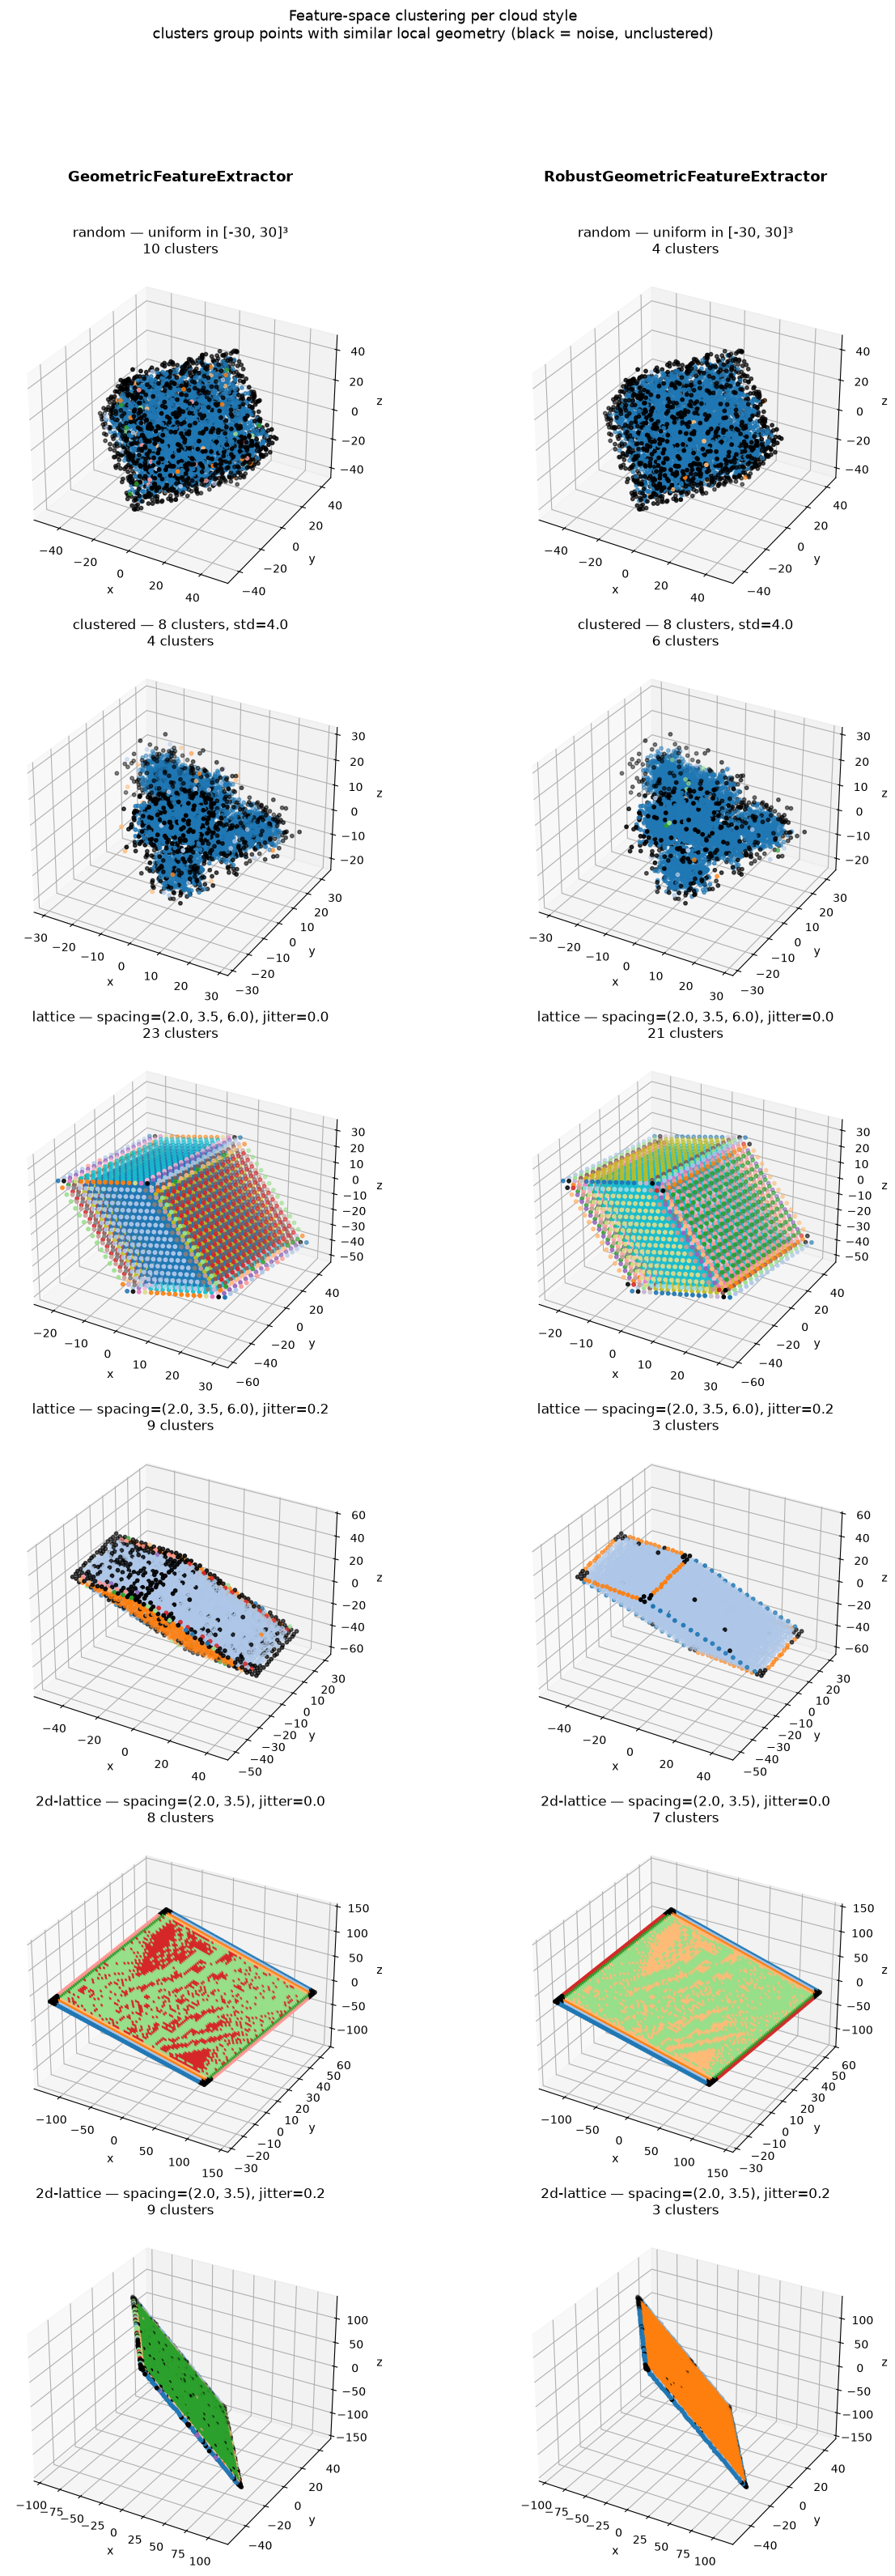

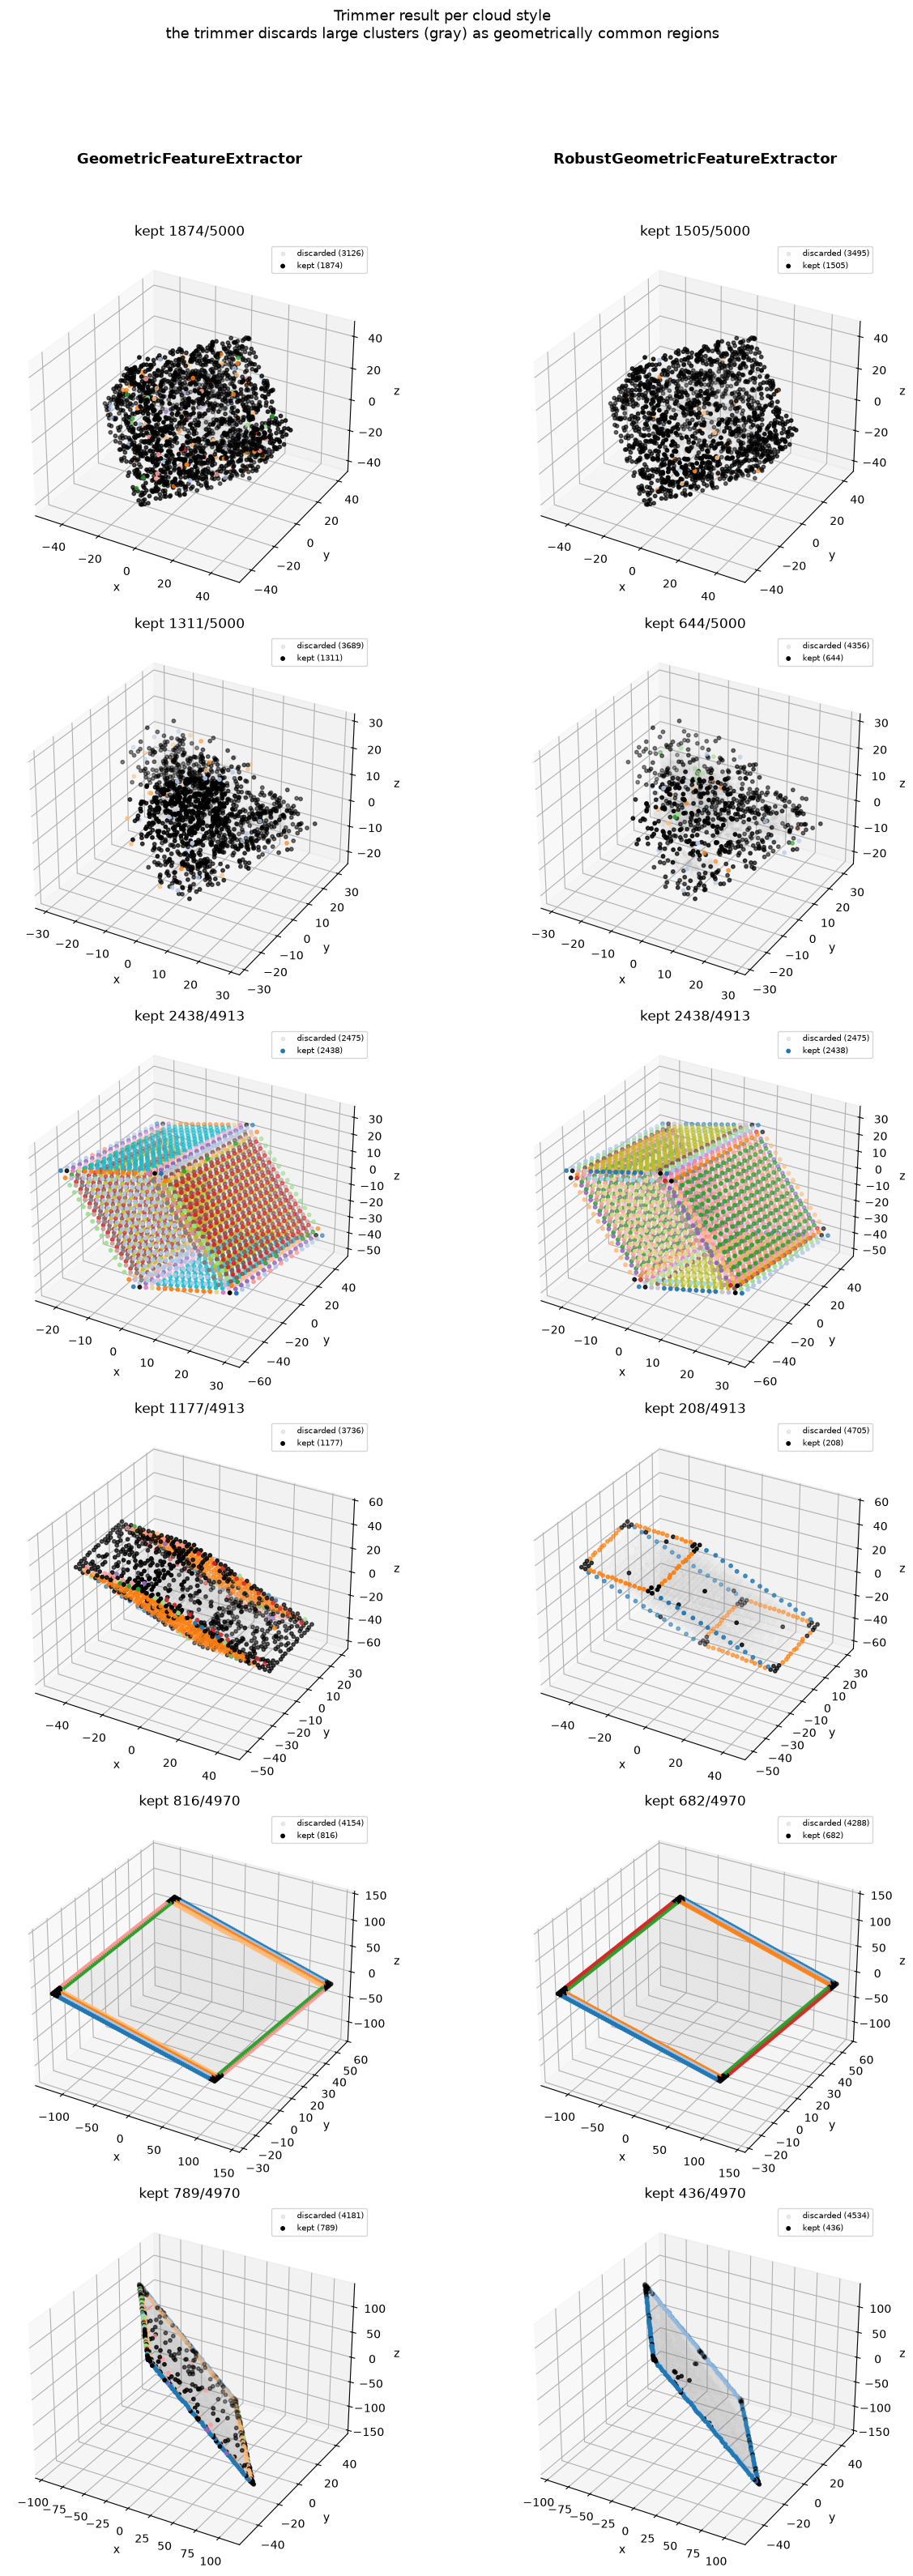

In [4]:
def render_comparison_grid(
    plot_cell: Callable[[Axes, tuple], None],
    suptitle: str,
    savepath: str,
) -> None:
    """Render an (N_SEEDS x len(EXTRACTOR_NAMES)) grid of 3D subplots and save it.

    Columns correspond to feature extractors (see EXTRACTOR_NAMES/results),
    rows to cloud style/jitter configs (see CONFIGS).

    Args:
        plot_cell: Called as plot_cell(ax, entry) for each cell, where entry is
                   one (cloud, labels, large_labels, style, jitter_std) tuple.
                   Must set the subplot's own title.
        suptitle: Figure-level title.
        savepath: Output PNG path.
    """
    n_cols = len(EXTRACTOR_NAMES)
    fig = plt.figure(figsize=(7 * n_cols, 5.4 * N_SEEDS))
    fig.suptitle(suptitle, fontsize=13)

    axes = [[None] * n_cols for _ in range(N_SEEDS)]
    for i in range(N_SEEDS):
        for j, name in enumerate(EXTRACTOR_NAMES):
            ax = fig.add_subplot(N_SEEDS, n_cols, n_cols * i + j + 1, projection='3d')
            plot_cell(ax, results[name][i])
            axes[i][j] = ax

    plt.tight_layout(rect=(0, 0, 1, 0.92))

    # Column headers, placed above the top row using its final (post-tight_layout) position.
    for j, name in enumerate(EXTRACTOR_NAMES):
        pos = axes[0][j].get_position()
        fig.text((pos.x0 + pos.x1) / 2, pos.y1 + 0.03, name, ha='center', fontsize=13, fontweight='bold')

    plt.savefig(savepath, dpi=300)
    plt.show()


def _plot_clusters_cell(ax: Axes, entry: tuple) -> None:
    """Draw feature-space cluster coloring for one (cloud, labels, ...) result entry."""
    cloud, labels, large_labels, style, jitter_std = entry
    n_clusters = np.unique(labels[labels >= 0]).size
    PointCloudVisualizer.plot_cluster_coloring(ax, cloud, labels)
    ax.set_title(f'{cloud_description(style, jitter_std)}\n{n_clusters} clusters')


def _plot_trimmer_cell(ax: Axes, entry: tuple) -> None:
    """Draw trimmer keep/discard result for one (cloud, labels, ...) result entry."""
    cloud, labels, large_labels, style, jitter_std = entry
    n_kept = (~np.isin(labels, list(large_labels))).sum()
    PointCloudVisualizer.plot_trimmer_result(ax, cloud, labels, large_labels)
    ax.set_title(f'kept {n_kept}/{len(cloud)}')


render_comparison_grid(
    _plot_clusters_cell,
    'Feature-space clustering per cloud style\nclusters group points with similar local '
    'geometry (black = noise, unclustered)',
    '../results/11_clustering_visualization_clusters.png',
)

render_comparison_grid(
    _plot_trimmer_cell,
    'Trimmer result per cloud style\nthe trimmer discards large clusters (gray) as '
    'geometrically common regions',
    '../results/11_clustering_visualization_trimmer.png',
)